# Data Science Assessment


### Data-driven assessment of public-transport attractiveness for employees of Johnson & Johnson Medical GmbH


**Pipeline covered:**
1. Synthetic employee dataset (no real employee data)
2. Public transport connection assessment (offline HVV rail-network model: U-Bahn / S-Bahn / AKN / regional)
3. Door-to-door commute time (walk / local bus + rail + transfers + last mile)
4. Commute-time grouping (≤30 / 31–45 / 46–60 / >60 min)
5. Deutschlandticket adoption scoring (transparent weighted utility model)
6. Summary findings + interactive map


In [1]:
import subprocess
import sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

required = ["numpy", "pandas", "networkx", "matplotlib", "folium"]
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installing {pkg} ...")
        install(pkg)

print("All packages ready ✓")

All packages ready ✓


In [2]:
import math
from functools import lru_cache

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster

pd.set_option('display.max_columns', 40)

In [3]:
from pathlib import Path
Path("data").mkdir(exist_ok=True)
Path("outputs").mkdir(exist_ok=True)

### Configuration- Model assumptions


In [4]:
# Workplace
OFFICE = {
    "name": "Johnson & Johnson Medical GmbH (Robert-Koch-Str. 1, Norderstedt)",
    "lat": 53.6872,
    "lon": 10.0459,
}

# Synthetic Data
N_EMPLOYEES = 500
RANDOM_SEED = 42

# Travel model assumptions
WALK_SPEED_KMH = 4.8         
DETOUR_FACTOR = 1.30          
MAX_WALK_TO_STATION_KM = 1.6  # Here assume that a local bus is used

# Local bus (last mile / first mile when no rail station is walkable)
BUS_SPEED_KMH = 18.0          
BUS_WAIT_MIN = 6.0            
BUS_ACCESS_WALK_MIN = 4.0    

# Railway connection
AVG_WAIT_MIN = {              
    "U": 3.0,                 # U-Bahn 
    "S": 4.0,                 # S-Bahn 
    "A": 7.5,                 # Altona
    "R": 15.0,                # Regional 
}
LINE_SPEED_KMH = {           
    "U": 32.0,
    "S": 38.0,
    "A": 45.0,
    "R": 70.0,
}
TRANSFER_PENALTY_MIN = 5.0    # per transfer: walk between platforms + wait


OFFICE_LAST_MILE = {
    "bus_from_stations": ["Norderstedt Mitte", "Ochsenzoll", "Kiwittsmoor", "Garstedt"],
}

# Car benchmark (used for the mode-choice comparison)
CAR_SPEED_KMH = 34.0          
CAR_FIXED_OVERHEAD_MIN = 6.0  
CAR_COST_PER_KM_EUR = 0.30    
WORKDAYS_PER_MONTH = 21


# Deutschlandticket
DTICKET_PRICE_EUR = 63.0      # monthly price since Jan 2026 
EMPLOYER_SUBSIDY_SHARE = 0.30 # typical Jobticket subsidy scenario 

# Commute-time buckets required by the challenge
TIME_BUCKETS = [(0, 30), (30, 45), (45, 60), (60, float("inf"))]
TIME_BUCKET_LABELS = ["<= 30 min", "31-45 min", "46-60 min", "> 60 min"]

# Adoption score thresholds
ADOPTION_HIGH = 0.55  
ADOPTION_MEDIUM = 0.42


### Geo helpers

In [5]:
def haversine_km(lat1, lon1, lat2, lon2) -> float:
    """Great-circle distance in km."""
    r = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dlmb / 2) ** 2
    return 2 * r * math.asin(math.sqrt(a))


def street_km(lat1, lon1, lat2, lon2, detour=1.30) -> float:
    """Approximate street-network distance from straight-line distance."""
    return haversine_km(lat1, lon1, lat2, lon2) * detour

### HVV rail network
nearly 120 stations with approximate coordinates (±100–300 m). Consecutive stations on a line become graph edges; stations shared by several lines become transfer nodes.

In [6]:
# name -> (lat, lon)
STATIONS = {
    # ---- U1 (north branch / Norderstedt) ----
    "Norderstedt Mitte": (53.7086, 9.9963),
    "Richtweg": (53.7008, 9.9930),
    "Garstedt": (53.6931, 9.9856),
    "Ochsenzoll": (53.6798, 9.9863),
    "Kiwittsmoor": (53.6723, 9.9910),
    "Langenhorn Nord": (53.6647, 9.9948),
    "Langenhorn Markt": (53.6530, 10.0000),
    "Fuhlsbuettel Nord": (53.6431, 10.0080),
    "Fuhlsbuettel": (53.6345, 10.0155),
    "Klein Borstel": (53.6262, 10.0270),
    "Ohlsdorf": (53.6208, 10.0316),
    "Sengelmannstrasse": (53.6055, 10.0210),
    "Alsterdorf": (53.5999, 10.0128),
    "Lattenkamp": (53.5940, 10.0056),
    "Hudtwalckerstrasse": (53.5877, 9.9971),
    "Kellinghusenstrasse": (53.5809, 9.9910),
    "Klosterstern": (53.5751, 9.9908),
    "Hallerstrasse": (53.5701, 9.9905),
    "Stephansplatz": (53.5571, 9.9903),
    "Jungfernstieg": (53.5527, 9.9932),
    "Hauptbahnhof": (53.5528, 10.0069),
    "Lohmuehlenstrasse": (53.5589, 10.0158),
    "Luebecker Strasse": (53.5620, 10.0270),
    "Wartenau": (53.5643, 10.0345),
    "Wandsbeker Chaussee": (53.5679, 10.0630),
    "Wandsbek Markt": (53.5721, 10.0788),
    "Strassburger Strasse": (53.5849, 10.0680),
    "Alter Teichweg": (53.5877, 10.0640),
    "Farmsen": (53.6062, 10.1172),
    "Berne": (53.6194, 10.1300),
    "Meiendorfer Weg": (53.6317, 10.1408),
    "Volksdorf": (53.6492, 10.1618),
    "Buckhorn": (53.6614, 10.1500),
    "Hoisbuettel": (53.6702, 10.1400),
    "Ohlstedt": (53.6790, 10.1310),
    "Ahrensburg West": (53.6660, 10.2100),
    "Ahrensburg Ost": (53.6720, 10.2320),
    "Grosshansdorf": (53.6620, 10.2620),

    # ---- U2 ----
    "Niendorf Nord": (53.6407, 9.9503),
    "Niendorf Markt": (53.6180, 9.9503),
    "Hagenbecks Tierpark": (53.5921, 9.9438),
    "Osterstrasse": (53.5770, 9.9550),
    "Schlump": (53.5678, 9.9700),
    "Gaensemarkt": (53.5562, 9.9868),
    "Berliner Tor": (53.5528, 10.0250),
    "Horner Rennbahn": (53.5560, 10.0900),
    "Billstedt": (53.5408, 10.1030),
    "Muemmelmannsberg": (53.5300, 10.1480),

    # ---- U3 (ring, partial) ----
    "Barmbek": (53.5872, 10.0443),
    "Saarlandstrasse": (53.5860, 10.0290),
    "Borgweg": (53.5867, 10.0170),
    "Sternschanze": (53.5635, 9.9662),
    "St. Pauli": (53.5502, 9.9700),
    "Landungsbruecken": (53.5460, 9.9714),
    "Rathaus": (53.5510, 9.9928),
    "Wandsbek-Gartenstadt": (53.5920, 10.0742),

    # ---- S1 ----
    "Wedel": (53.5813, 9.7040),
    "Rissen": (53.5830, 9.7550),
    "Blankenese": (53.5632, 9.8202),
    "Klein Flottbek": (53.5630, 9.8630),
    "Othmarschen": (53.5620, 9.8940),
    "Bahrenfeld": (53.5600, 9.9105),
    "Altona": (53.5520, 9.9350),
    "Reeperbahn": (53.5498, 9.9640),
    "Stadthausbruecke": (53.5493, 9.9840),
    "Landwehr": (53.5606, 10.0350),
    "Hasselbrook": (53.5640, 10.0430),
    "Friedrichsberg": (53.5790, 10.0480),
    "Alte Woehr": (53.5980, 10.0450),
    "Ruebenkamp": (53.6110, 10.0400),
    "Hamburg Airport": (53.6320, 10.0064),
    "Kornweg": (53.6320, 10.0450),
    "Hoheneichen": (53.6400, 10.0550),
    "Wellingsbuettel": (53.6410, 10.0800),
    "Poppenbuettel": (53.6585, 10.0850),

    # ---- S2/S3 south + west ----
    "Hammerbrook": (53.5460, 10.0230),
    "Elbbruecken": (53.5350, 10.0230),
    "Veddel": (53.5230, 10.0130),
    "Wilhelmsburg": (53.4990, 10.0060),
    "Harburg": (53.4560, 9.9830),
    "Harburg Rathaus": (53.4600, 9.9800),
    "Neugraben": (53.4738, 9.8530),
    "Holstenstrasse": (53.5580, 9.9448),
    "Diebsteich": (53.5680, 9.9330),
    "Langenfelde": (53.5760, 9.9280),
    "Stellingen": (53.5890, 9.9180),
    "Eidelstedt": (53.5963, 9.9060),
    "Elbgaustrasse": (53.6020, 9.8930),
    "Krupunder": (53.6210, 9.8720),
    "Halstenbek": (53.6350, 9.8560),
    "Thesdorf": (53.6440, 9.8210),
    "Pinneberg": (53.6520, 9.7900),

    # ---- AKN A1 / A2 (crucial for Norderstedt / Quickborn corridor) ----
    "Eidelstedt Zentrum": (53.6070, 9.9050),
    "Schnelsen": (53.6320, 9.9210),
    "Burgwedel": (53.6420, 9.9130),
    "Boenningstedt": (53.6690, 9.9110),
    "Hasloh": (53.6970, 9.9080),
    "Quickborn": (53.7280, 9.9030),
    "Ellerau": (53.7550, 9.9210),
    "Ulzburg Sued": (53.7860, 9.9800),
    "Henstedt-Ulzburg": (53.7950, 9.9770),
    "Kaltenkirchen": (53.8360, 9.9580),
    # A2: Norderstedt Mitte <-> Ulzburg Sued
    "Friedrichsgabe": (53.7250, 9.9820),
    "Meeschensee": (53.7410, 9.9760),

    # ---- Regional (selected) ----
    "Elmshorn": (53.7530, 9.6530),
    "Tornesch": (53.7040, 9.7160),
    "Prisdorf": (53.6660, 9.7580),
    "Dammtor": (53.5606, 9.9895),
    "Bergedorf": (53.4890, 10.2070),
    "Rahlstedt": (53.6020, 10.1560),
    "Bad Oldesloe": (53.8080, 10.3660),
    "Bargteheide": (53.7280, 10.2660),
    "Ahrensburg": (53.6740, 10.2260),
}

# mode letter: U / S / A (AKN) / R (regional)
LINES = {
    "U1": ["Norderstedt Mitte", "Richtweg", "Garstedt", "Ochsenzoll", "Kiwittsmoor",
            "Langenhorn Nord", "Langenhorn Markt", "Fuhlsbuettel Nord", "Fuhlsbuettel",
            "Klein Borstel", "Ohlsdorf", "Sengelmannstrasse", "Alsterdorf", "Lattenkamp",
            "Hudtwalckerstrasse", "Kellinghusenstrasse", "Klosterstern", "Hallerstrasse",
            "Stephansplatz", "Jungfernstieg", "Hauptbahnhof", "Lohmuehlenstrasse",
            "Luebecker Strasse", "Wartenau", "Wandsbeker Chaussee", "Wandsbek Markt",
            "Strassburger Strasse", "Alter Teichweg", "Farmsen", "Berne",
            "Meiendorfer Weg", "Volksdorf", "Buckhorn", "Hoisbuettel", "Ohlstedt"],
    "U1-Ahrensburg": ["Volksdorf", "Ahrensburg West", "Ahrensburg Ost", "Grosshansdorf"],
    "U2": ["Niendorf Nord", "Niendorf Markt", "Hagenbecks Tierpark", "Osterstrasse",
            "Schlump", "Gaensemarkt", "Jungfernstieg", "Hauptbahnhof", "Berliner Tor",
            "Horner Rennbahn", "Billstedt", "Muemmelmannsberg"],
    "U3": ["Barmbek", "Saarlandstrasse", "Borgweg", "Kellinghusenstrasse", "Schlump",
            "Sternschanze", "St. Pauli", "Landungsbruecken", "Rathaus", "Hauptbahnhof",
            "Berliner Tor", "Hamburger Strasse Stub"],
    "U3-Nord": ["Barmbek", "Wandsbek-Gartenstadt"],
    "S1-West": ["Wedel", "Rissen", "Blankenese", "Klein Flottbek", "Othmarschen",
                 "Bahrenfeld", "Altona", "Reeperbahn", "Landungsbruecken",
                 "Stadthausbruecke", "Jungfernstieg", "Hauptbahnhof"],
    "S1-Ost": ["Hauptbahnhof", "Landwehr", "Hasselbrook", "Wandsbeker Chaussee",
                "Friedrichsberg", "Barmbek", "Alte Woehr", "Ruebenkamp", "Ohlsdorf"],
    "S1-Airport": ["Ohlsdorf", "Hamburg Airport"],
    "S1-Poppenbuettel": ["Ohlsdorf", "Kornweg", "Hoheneichen", "Wellingsbuettel",
                          "Poppenbuettel"],
    "S3-Sued": ["Hauptbahnhof", "Hammerbrook", "Elbbruecken", "Veddel", "Wilhelmsburg",
                 "Harburg", "Harburg Rathaus", "Neugraben"],
    "S3-West": ["Hauptbahnhof", "Jungfernstieg", "Stadthausbruecke", "Landungsbruecken",
                 "Reeperbahn", "Altona", "Holstenstrasse", "Diebsteich", "Langenfelde",
                 "Stellingen", "Eidelstedt", "Elbgaustrasse", "Krupunder", "Halstenbek",
                 "Thesdorf", "Pinneberg"],
    "A1": ["Eidelstedt", "Eidelstedt Zentrum", "Schnelsen", "Burgwedel", "Boenningstedt",
            "Hasloh", "Quickborn", "Ellerau", "Ulzburg Sued", "Henstedt-Ulzburg",
            "Kaltenkirchen"],
    "A2": ["Norderstedt Mitte", "Friedrichsgabe", "Meeschensee", "Ulzburg Sued"],
    "RB-Elmshorn": ["Elmshorn", "Tornesch", "Prisdorf", "Pinneberg", "Dammtor",
                     "Hauptbahnhof"],
    "RB-Ost": ["Hauptbahnhof", "Rahlstedt", "Ahrensburg", "Bargteheide", "Bad Oldesloe"],
    "RB-Bergedorf": ["Hauptbahnhof", "Bergedorf"],
}

# remove a placeholder that has no coordinates
LINES["U3"] = [s for s in LINES["U3"] if s in STATIONS]


def line_mode(line_name: str) -> str:
    """First letter of the line name gives the mode (U/S/A/R)."""
    c = line_name[0]
    return c if c in "USA" else "R"


### 1 · Synthetic data generation
Employees are sampled from a weighted mixture of ~35 residential areas across Hamburg and the northern commuter belt. Weights approximate population size with a mild extra weight on northern districts (people tend to live near their workplace). Each employee also gets **mode-choice drivers**: car ownership (lower in the urban core), home-office days, an existing transit-pass flag, and an eco-affinity score.

In [7]:
# (name, lat, lon, sigma_km, weight)
# sigma_km controls how spread out the sampled homes are around the centre.
AREAS = [
    # Norderstedt & northern belt (extra weight: local workforce)
    ("Norderstedt-Mitte",   53.7060, 9.9990, 1.2, 8.0),
    ("Norderstedt-Glashuette", 53.6880, 10.0450, 1.0, 6.0),
    ("Garstedt",            53.6930, 9.9800, 1.0, 5.0),
    ("Henstedt-Ulzburg",    53.7950, 9.9770, 1.5, 4.0),
    ("Quickborn",           53.7280, 9.9030, 1.3, 3.5),
    ("Kaltenkirchen",       53.8360, 9.9580, 1.3, 2.0),
    ("Ellerau",             53.7550, 9.9210, 0.8, 1.0),
    ("Tangstedt",           53.7350, 10.0800, 1.5, 1.5),
    ("Bad Bramstedt",       53.9190, 9.8830, 1.2, 1.0),

    # Hamburg north
    ("Langenhorn",          53.6550, 10.0050, 1.3, 6.0),
    ("Fuhlsbuettel",        53.6340, 10.0160, 1.0, 3.0),
    ("Niendorf",            53.6180, 9.9500, 1.3, 4.0),
    ("Schnelsen",           53.6330, 9.9200, 1.2, 3.0),
    ("Poppenbuettel",       53.6590, 10.0850, 1.3, 3.0),
    ("Volksdorf",           53.6490, 10.1620, 1.3, 2.5),
    ("Bramfeld",            53.6150, 10.0720, 1.3, 3.5),
    ("Ohlsdorf",            53.6250, 10.0320, 1.0, 2.0),

    # Hamburg core
    ("Winterhude",          53.5950, 10.0000, 1.2, 4.0),
    ("Eppendorf",           53.5900, 9.9850, 1.0, 3.0),
    ("Eimsbuettel",         53.5760, 9.9550, 1.2, 4.0),
    ("Barmbek",             53.5870, 10.0440, 1.2, 4.0),
    ("Wandsbek",            53.5720, 10.0790, 1.3, 3.5),
    ("St. Georg / Altstadt",53.5540, 10.0100, 1.0, 2.5),
    ("Altona",              53.5520, 9.9350, 1.3, 3.0),
    ("St. Pauli",           53.5500, 9.9660, 0.9, 1.5),

    # Hamburg east / south / west (long commutes - important contrast group)
    ("Rahlstedt",           53.6020, 10.1560, 1.5, 3.0),
    ("Billstedt",           53.5410, 10.1030, 1.4, 2.5),
    ("Bergedorf",           53.4890, 10.2070, 1.5, 1.5),
    ("Harburg",             53.4590, 9.9820, 1.5, 2.0),
    ("Blankenese",          53.5630, 9.8200, 1.2, 1.5),
    ("Wedel",               53.5830, 9.7080, 1.2, 1.0),
    ("Pinneberg",           53.6550, 9.7950, 1.3, 2.0),
    ("Halstenbek",          53.6350, 9.8560, 1.0, 1.5),
    ("Ahrensburg",          53.6740, 10.2260, 1.3, 2.0),
    ("Elmshorn",            53.7540, 9.6540, 1.4, 1.5),
]

KM_PER_DEG_LAT = 111.0


def generate_employees(n: int = N_EMPLOYEES,
                       seed: int = RANDOM_SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    weights = np.array([a[4] for a in AREAS], dtype=float)
    weights /= weights.sum()
    idx = rng.choice(len(AREAS), size=n, p=weights)

    rows = []
    for i, ai in enumerate(idx):
        name, lat0, lon0, sigma_km, _ = AREAS[ai]
        km_per_deg_lon = KM_PER_DEG_LAT * np.cos(np.radians(lat0))
        lat = lat0 + rng.normal(0, sigma_km / KM_PER_DEG_LAT)
        lon = lon0 + rng.normal(0, sigma_km / km_per_deg_lon)

        age = int(np.clip(rng.normal(41, 11), 19, 66))
        # car ownership is lower in the urban core, higher in the belt
        urban_core = name in {"Winterhude", "Eppendorf", "Eimsbuettel", "Barmbek",
                              "St. Georg / Altstadt", "Altona", "St. Pauli"}
        p_car = 0.55 if urban_core else 0.85
        has_car = rng.random() < p_car
        home_office_days = int(rng.choice([0, 1, 2, 3], p=[0.35, 0.25, 0.25, 0.15]))
        has_transit_pass = rng.random() < (0.45 if urban_core else 0.20)
        eco_affinity = float(np.clip(rng.beta(2.2, 2.2), 0, 1))  # 0..1
        salary_band = rng.choice(["junior", "mid", "senior"], p=[0.3, 0.5, 0.2])

        rows.append({
            "employee_id": f"E{i+1:04d}",
            "area": name,
            "home_lat": round(float(lat), 6),
            "home_lon": round(float(lon), 6),
            "age": age,
            "salary_band": salary_band,
            "has_car": has_car,
            "has_transit_pass_already": has_transit_pass,
            "home_office_days_per_week": home_office_days,
            "eco_affinity": round(eco_affinity, 3),
        })

    return pd.DataFrame(rows)


In [8]:
employees = generate_employees()
print(len(employees), 'synthetic employees')
display(employees.head(8))
employees['area'].value_counts().head(12)

500 synthetic employees


,employee_id,area,home_lat,home_lon,age,salary_band,has_car,has_transit_pass_already,home_office_days_per_week,eco_affinity
0,E0001,St. Georg / Altstadt,53.566912,10.011388,47,junior,True,False,1,0.462
1,E0002,Schnelsen,53.629905,9.928277,37,mid,True,True,2,0.054
2,E0003,Billstedt,53.522050,10.040079,35,junior,False,False,2,0.634
3,E0004,Barmbek,53.595549,10.050277,48,mid,True,False,2,0.160
4,E0005,Norderstedt-Glashuette,53.684013,10.067136,42,junior,True,True,1,0.250
5,E0006,Ahrensburg,53.667690,10.248693,19,junior,True,False,0,0.591
6,E0007,St. Georg / Altstadt,53.544914,10.020719,48,senior,False,False,1,0.809
7,E0008,Altona,53.537425,9.917479,40,mid,False,True,2,0.671


Norderstedt-Glashuette    42
Garstedt                  32
Norderstedt-Mitte         31
Altona                    28
Eimsbuettel               23
Winterhude                21
Barmbek                   20
Langenhorn                20
Schnelsen                 18
Niendorf                  18
Quickborn                 17
Poppenbuettel             17
Name: area, dtype: int64

### 2 & 3 · PT connection assessment & door-to-door commute time
For every employee the model finds the fastest combination of

`walk / local-bus → origin station → Dijkstra through the HVV rail graph (incl. initial wait & transfer penalties) → arrival station → last mile to the office`

plus a **car benchmark** (congestion-adjusted speed + full cost ~€0.30/km) for the mode-choice comparison.

In [9]:
# Network graph
def build_graph() -> nx.Graph:
    """Nodes are (station, line); a station shared by lines gets transfer
    edges between its line-nodes. This models transfer penalties cleanly."""
    g = nx.Graph()
    for line, stops in LINES.items():
        mode = line_mode(line)
        speed = LINE_SPEED_KMH[mode]
        for a, b in zip(stops[:-1], stops[1:]):
            (la, lo), (lb, lob) = STATIONS[a], STATIONS[b]
            km = haversine_km(la, lo, lb, lob) * 1.15  # track curvature
            minutes = km / speed * 60 + 0.7            # + dwell time
            g.add_edge((a, line), (b, line), minutes=minutes)

    # transfer edges at shared stations
    by_station = {}
    for node in g.nodes:
        by_station.setdefault(node[0], []).append(node)
    for station, nodes in by_station.items():
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                g.add_edge(nodes[i], nodes[j],
                           minutes=TRANSFER_PENALTY_MIN)
    return g


GRAPH = build_graph()
STATION_LIST = list(STATIONS.items())


def nearest_stations(lat, lon, k=4):
    """k nearest rail stations with straight-line distance."""
    d = [(name, haversine_km(lat, lon, la, lo))
         for name, (la, lo) in STATION_LIST]
    d.sort(key=lambda t: t[1])
    return d[:k]


def access_time_min(dist_km_straight: float) -> tuple[float, str]:
    """First/last-mile time from a point to a station.

    Short distances -> walk; longer -> local bus (wait + ride + stop walk).
    Returns (minutes, mode)."""
    walk_km = dist_km_straight * DETOUR_FACTOR
    walk_min = walk_km / WALK_SPEED_KMH * 60
    if dist_km_straight <= MAX_WALK_TO_STATION_KM:
        return walk_min, "walk"
    bus_min = (BUS_ACCESS_WALK_MIN + BUS_WAIT_MIN
               + walk_km / BUS_SPEED_KMH * 60)
    if bus_min < walk_min:
        return bus_min, "bus"
    return walk_min, "walk"


@lru_cache(maxsize=None)
def ride_minutes(origin: str, dest: str) -> tuple[float, int, str]:
    """Shortest ride between two stations.

    Returns (in-vehicle+transfer minutes incl. initial wait, n_transfers,
    first_line)."""
    best = None
    origin_nodes = [n for n in GRAPH.nodes if n[0] == origin]
    dest_nodes = {n for n in GRAPH.nodes if n[0] == dest}
    for on in origin_nodes:
        try:
            lengths, paths = nx.single_source_dijkstra(GRAPH, on, weight="minutes")
        except nx.NetworkXNoPath:
            continue
        for dn in dest_nodes:
            if dn in lengths:
                path = paths[dn]
                lines_used = []
                for node in path:
                    if not lines_used or lines_used[-1] != node[1]:
                        lines_used.append(node[1])
                # collapse branch names of the same physical line (U1 & U1-Ahrensburg)
                transfers = max(0, len({l.split("-")[0] for l in lines_used}) - 1)
                first_line = lines_used[0]
                wait = AVG_WAIT_MIN[line_mode(first_line)]
                total = lengths[dn] + wait
                cand = (total, transfers, first_line)
                if best is None or cand[0] < best[0]:
                    best = cand
    if best is None:
        return float("inf"), 0, ""
    return best


# Pre-compute office egress options: from candidate arrival stations to office
def _office_egress():
    out = {}
    olat, olon = OFFICE["lat"], OFFICE["lon"]
    for name, dkm in nearest_stations(olat, olon, k=8):
        minutes, mode = access_time_min(dkm)
        out[name] = (minutes, mode, dkm)
    return out


OFFICE_EGRESS = _office_egress()


def pt_commute(lat: float, lon: float) -> dict:
    """Best door-to-door PT commute from a home coordinate to the office."""
    best = None
    for origin, dist_km in nearest_stations(lat, lon, k=4):
        a_min, a_mode = access_time_min(dist_km)
        for dest, (e_min, e_mode, _) in OFFICE_EGRESS.items():
            if origin == dest:
                # walk/bus the whole way without rail
                total_km = haversine_km(lat, lon, OFFICE["lat"],
                                        OFFICE["lon"])
                direct_min, direct_mode = access_time_min(total_km)
                cand = dict(total_min=direct_min, ride_min=0.0, access_min=direct_min,
                            egress_min=0.0, transfers=0, origin_station="(direct)",
                            dest_station="(direct)", access_mode=direct_mode,
                            egress_mode="-", first_line="none")
            else:
                r_min, transfers, first_line = ride_minutes(origin, dest)
                if r_min == float("inf"):
                    continue
                cand = dict(total_min=a_min + r_min + e_min, ride_min=r_min,
                            access_min=a_min, egress_min=e_min, transfers=transfers,
                            origin_station=origin, dest_station=dest,
                            access_mode=a_mode, egress_mode=e_mode,
                            first_line=first_line)
            if best is None or cand["total_min"] < best["total_min"]:
                best = cand

    # pure walk/bus fallback (relevant for homes in Glashuette itself)
    total_km = haversine_km(lat, lon, OFFICE["lat"], OFFICE["lon"])
    direct_min, direct_mode = access_time_min(total_km)
    if best is None or direct_min < best["total_min"]:
        best = dict(total_min=direct_min, ride_min=0.0, access_min=direct_min,
                    egress_min=0.0, transfers=0, origin_station="(direct)",
                    dest_station="(direct)", access_mode=direct_mode,
                    egress_mode="-", first_line="none")
    return best


def car_commute(lat: float, lon: float) -> dict:
    km = street_km(lat, lon, OFFICE["lat"], OFFICE["lon"])
    minutes = km / CAR_SPEED_KMH * 60 + CAR_FIXED_OVERHEAD_MIN
    monthly_cost = km * 2 * CAR_COST_PER_KM_EUR * WORKDAYS_PER_MONTH
    return {"car_min": minutes, "car_km_oneway": km,
            "car_monthly_cost_eur": monthly_cost}


def compute_commutes(employees: pd.DataFrame) -> pd.DataFrame:
    """Enrich the employee frame with PT and car commute metrics."""
    records = []
    for _, e in employees.iterrows():
        pt = pt_commute(e.home_lat, e.home_lon)
        car = car_commute(e.home_lat, e.home_lon)
        records.append({**pt, **car})
    out = pd.concat([employees.reset_index(drop=True),
                     pd.DataFrame(records)], axis=1)

    # commute-time bucket (Step 4)
    def bucket(t):
        for (lo, hi), label in zip(TIME_BUCKETS, TIME_BUCKET_LABELS):
            if lo < t <= hi or (lo == 0 and t <= hi):
                return label
        return TIME_BUCKET_LABELS[-1]
    out["commute_bucket"] = out["total_min"].apply(bucket)
    out = out.rename(columns={"total_min": "pt_door_to_door_min"})
    return out


In [10]:
print('Office egress options (arrival station -> office):')
for st_, (mins, mode, km) in sorted(OFFICE_EGRESS.items(), key=lambda kv: kv[1][0]):
    print(f'  {st_:<20} {km:4.1f} km  ->  {mins:4.1f} min by {mode}')

Office egress options (arrival station -> office):
  Richtweg              3.8 km  ->  26.5 min by bus
  Kiwittsmoor           4.0 km  ->  27.2 min by bus
  Ochsenzoll            4.0 km  ->  27.4 min by bus
  Garstedt              4.0 km  ->  27.4 min by bus
  Norderstedt Mitte     4.0 km  ->  27.5 min by bus
  Poppenbuettel         4.1 km  ->  27.8 min by bus
  Langenhorn Nord       4.2 km  ->  28.2 min by bus
  Langenhorn Markt      4.9 km  ->  31.1 min by bus


In [11]:
%%time
commutes = compute_commutes(employees)
commutes[['employee_id','area','pt_door_to_door_min','access_min','ride_min',
          'egress_min','transfers','origin_station','dest_station',
          'car_min','car_monthly_cost_eur','commute_bucket']].head(8)

CPU times: total: 484 ms
Wall time: 1.44 s


,employee_id,area,pt_door_to_door_min,access_min,ride_min,egress_min,transfers,origin_station,dest_station,car_min,car_monthly_cost_eur,commute_bucket
0,E0001,St. Georg / Altstadt,68.793143,68.793143,0.0,0.0,0,(direct),(direct),37.125782,222.238082,> 60 min
1,E0002,Schnelsen,53.476199,53.476199,0.0,0.0,0,(direct),(direct),29.016811,164.340032,46-60 min
2,E0003,Billstedt,89.594050,89.594050,0.0,0.0,0,(direct),(direct),48.138027,300.865510,> 60 min
3,E0004,Barmbek,54.179243,54.179243,0.0,0.0,0,(direct),(direct),29.389011,166.997539,46-60 min
4,E0005,Norderstedt-Glashuette,23.442627,23.442627,0.0,0.0,0,(direct),(direct),9.309547,23.630168,<= 30 min
5,E0006,Ahrensburg,68.637852,68.637852,0.0,0.0,0,(direct),(direct),37.043569,221.651082,> 60 min
6,E0007,St. Georg / Altstadt,78.936508,78.936508,0.0,0.0,0,(direct),(direct),42.495799,260.580002,> 60 min
7,E0008,Altona,90.968142,90.968142,0.0,0.0,0,(direct),(direct),48.865487,306.059576,> 60 min


### 4 · Commute-time grouping

In [12]:
def bucket_table(df):
    t = (df['commute_bucket'].value_counts()
         .reindex(TIME_BUCKET_LABELS).fillna(0).astype(int)
         .rename('employees').to_frame())
    t['share_%'] = (t['employees'] / len(df) * 100).round(1)
    cum = df['pt_door_to_door_min']
    within = {f'within {m} min': round((cum <= m).mean() * 100, 1) for m in (30, 45, 60)}
    within['over 60 min'] = round((cum > 60).mean() * 100, 1)
    t.attrs['within'] = within
    return t

bt = bucket_table(commutes)
print('Cumulative view:', bt.attrs['within'])
bt

Cumulative view: {'within 30 min': 21.4, 'within 45 min': 36.8, 'within 60 min': 58.6, 'over 60 min': 41.4}


,employees,share_%
<= 30 min,107,21.4
31-45 min,77,15.4
46-60 min,109,21.8
> 60 min,207,41.4


### 5 · Deutschlandticket adoption scoring
No ground-truth adoption data exists, so instead of a black-box model I use a **transparent weighted utility score** (0–1) — every factor is documented and can be recalibrated with survey data later:

| Sub-score | Weight | Intuition |
|---|---|---|
| Time competitiveness (PT vs car) | 0.30 | People switch when PT is not much slower than driving |
| Absolute door-to-door time | 0.20 | <30 min is attractive regardless of the car comparison |
| Cost advantage | 0.20 | €63/month − 30 % employer subsidy vs ~€0.30/km driving |
| Convenience (transfers, first/last mile) | 0.15 | Transfers and long local legs deter adoption |
| Personal context | 0.15 | No car / existing pass / home office / eco affinity |

In [13]:
WEIGHTS = {
    "time_competitiveness": 0.30,
    "absolute_time": 0.20,
    "cost_advantage": 0.20,
    "convenience": 0.15,
    "personal_context": 0.15,
}


def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def score(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    effective_price = DTICKET_PRICE_EUR * (1 - EMPLOYER_SUBSIDY_SHARE)

    # 1. PT vs car time ratio: 1.0 -> equal, <1 PT faster.
    ratio = d["pt_door_to_door_min"] / d["car_min"].clip(lower=1)
    s_ratio = _sigmoid((1.45 - ratio) * 4.0)          # ratio 1.45 -> 0.5

    # 2. absolute door-to-door time: 35 min -> 0.5 midpoint
    s_abs = _sigmoid((45 - d["pt_door_to_door_min"]) / 12.0)

    # 3. monthly savings vs car (for non-car owners cost always favours PT)
    savings = d["car_monthly_cost_eur"] - effective_price
    s_cost = _sigmoid(savings / 60.0)
    s_cost = np.where(d["has_car"], s_cost, 0.9)

    # 4. convenience: transfers + access/egress share
    firstlast = d["access_min"] + d["egress_min"]
    s_conv = (_sigmoid((2.0 - d["transfers"]) * 1.5) * 0.5
              + _sigmoid((22 - firstlast) / 6.0) * 0.5)

    # 5. personal context
    ho = d["home_office_days_per_week"]
    s_pers = (0.45 * (~d["has_car"]).astype(float)
              + 0.25 * d["has_transit_pass_already"].astype(float)
              + 0.20 * d["eco_affinity"]
              + 0.10 * (1 - ho / 4.0))

    d["score_time_competitiveness"] = np.round(s_ratio, 3)
    d["score_absolute_time"] = np.round(s_abs, 3)
    d["score_cost_advantage"] = np.round(s_cost, 3)
    d["score_convenience"] = np.round(s_conv, 3)
    d["score_personal_context"] = np.round(s_pers, 3)

    d["adoption_score"] = np.round(
        WEIGHTS["time_competitiveness"] * s_ratio
        + WEIGHTS["absolute_time"] * s_abs
        + WEIGHTS["cost_advantage"] * s_cost
        + WEIGHTS["convenience"] * s_conv
        + WEIGHTS["personal_context"] * s_pers, 3)

    d["adoption_category"] = pd.cut(
        d["adoption_score"],
        bins=[-0.01, ADOPTION_MEDIUM, ADOPTION_HIGH, 1.01],
        labels=["Low", "Medium", "High"])

    d["monthly_savings_vs_car_eur"] = np.round(savings, 2)
    return d


In [14]:
scored = score(commutes)
display(scored[['employee_id','area','pt_door_to_door_min','car_min',
        'monthly_savings_vs_car_eur','adoption_score','adoption_category']].head(8))
(scored['adoption_category'].value_counts(normalize=True).round(3) * 100)

,employee_id,area,pt_door_to_door_min,car_min,monthly_savings_vs_car_eur,adoption_score,adoption_category
0,E0001,St. Georg / Altstadt,68.793143,37.125782,178.14,0.361,Low
1,E0002,Schnelsen,53.476199,29.016811,120.24,0.412,Low
2,E0003,Billstedt,89.594050,48.138027,256.77,0.399,Low
3,E0004,Barmbek,54.179243,29.389011,122.90,0.376,Low
4,E0005,Norderstedt-Glashuette,23.442627,9.309547,-20.47,0.419,Low
5,E0006,Ahrensburg,68.637852,37.043569,177.55,0.369,Low
6,E0007,St. Georg / Altstadt,78.936508,42.495799,216.48,0.415,Low
7,E0008,Altona,90.968142,48.865487,261.96,0.437,Medium


Low       48.0
Medium    46.4
High       5.6
Name: adoption_category, dtype: float64

### 6 · Summary findings

In [15]:
def area_summary(df):
    return (df.groupby('area')
              .agg(n=('employee_id','count'),
                   median_pt_min=('pt_door_to_door_min','median'),
                   mean_transfers=('transfers','mean'),
                   mean_adoption=('adoption_score','mean'),
                   high_share=('adoption_category', lambda s: (s=='High').mean()))
              .round(2).sort_values('mean_adoption', ascending=False))

within = bt.attrs['within']
cat = scored['adoption_category'].value_counts(normalize=True) * 100
areas = area_summary(scored)

print('DOOR-TO-DOOR PT COMMUTE TIMES')
for k, v in within.items():
    print(f'  {k:>14}: {v:5.1f} % of employees')
print()
print('DEUTSCHLANDTICKET ADOPTION POTENTIAL')
print(f"  Mean adoption score: {scored['adoption_score'].mean():.2f} (0-1)")
for c in ['High','Medium','Low']:
    print(f'  {c:>6} potential: {cat.get(c,0):5.1f} %')
print(f"  Expected adopters (sum of probabilities): ~{scored['adoption_score'].sum():.0f} of {len(scored)}")
print()
print('KEY FACTORS (correlation with adoption score)')
corr = scored[['pt_door_to_door_min','transfers','access_min','egress_min',
               'monthly_savings_vs_car_eur','eco_affinity',
               'home_office_days_per_week','adoption_score']].corr()['adoption_score'].drop('adoption_score').sort_values()
for k, v in corr.items():
    print(f'  {k:<32} {v:+.2f}')
print()
print('Note: cost savings correlate NEGATIVELY overall — savings grow with')
print('distance, and long distances also mean long PT times; the time')
print('penalty dominates. Classic confounding worth mentioning in review.')

DOOR-TO-DOOR PT COMMUTE TIMES
   within 30 min:  21.4 % of employees
   within 45 min:  36.8 % of employees
   within 60 min:  58.6 % of employees
     over 60 min:  41.4 % of employees

DEUTSCHLANDTICKET ADOPTION POTENTIAL
  Mean adoption score: 0.43 (0-1)
    High potential:   5.6 %
  Medium potential:  46.4 %
     Low potential:  48.0 %
  Expected adopters (sum of probabilities): ~215 of 500

KEY FACTORS (correlation with adoption score)
  pt_door_to_door_min              -0.66
  monthly_savings_vs_car_eur       -0.64
  access_min                       -0.60
  egress_min                       -0.15
  transfers                        -0.12
  home_office_days_per_week        -0.05
  eco_affinity                     +0.09

Note: cost savings correlate NEGATIVELY overall — savings grow with
distance, and long distances also mean long PT times; the time
penalty dominates. Classic confounding worth mentioning in review.


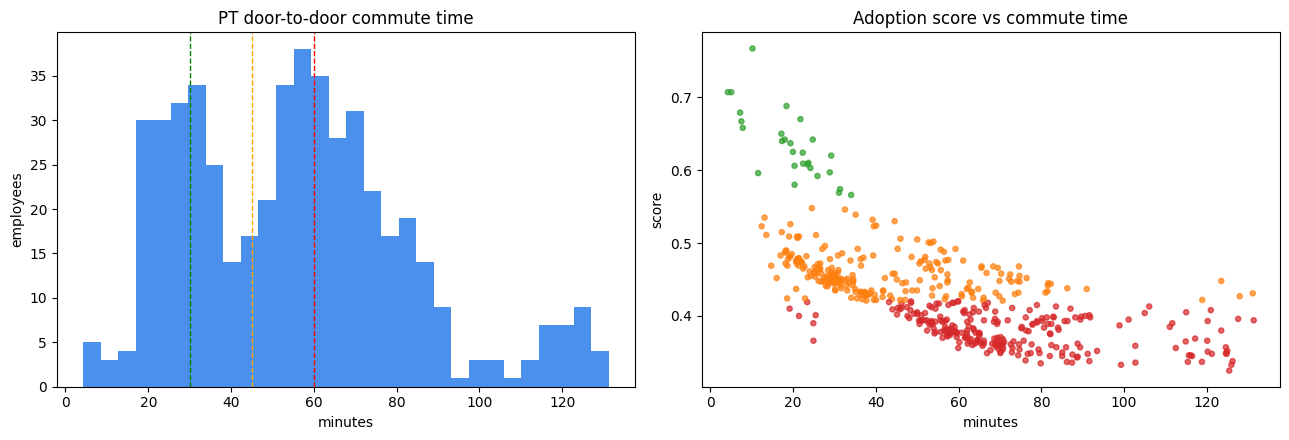

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(scored['pt_door_to_door_min'], bins=30, color='#2b7de9', alpha=.85)
for m, c in [(30,'green'),(45,'orange'),(60,'red')]:
    axes[0].axvline(m, color=c, ls='--', lw=1)
axes[0].set_title('PT door-to-door commute time'); axes[0].set_xlabel('minutes'); axes[0].set_ylabel('employees')

colors = scored['adoption_category'].map({'High':'#2ca02c','Medium':'#ff7f0e','Low':'#d62728'})
axes[1].scatter(scored['pt_door_to_door_min'], scored['adoption_score'], c=colors, s=14, alpha=.7)
axes[1].set_title('Adoption score vs commute time'); axes[1].set_xlabel('minutes'); axes[1].set_ylabel('score')
plt.tight_layout()
plt.savefig('outputs/commute_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

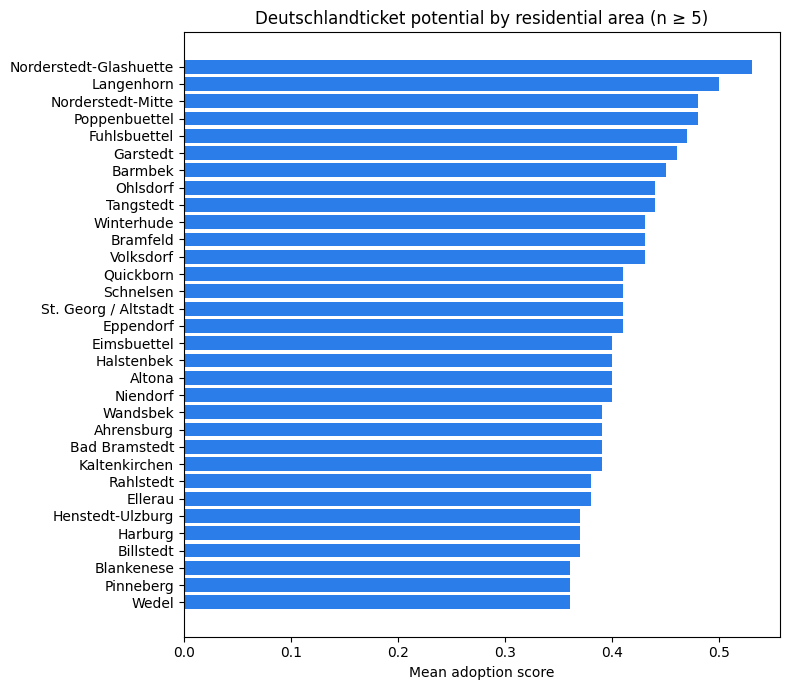

,n,median_pt_min,mean_transfers,mean_adoption,high_share
area,,,,,
Norderstedt-Glashuette,42,18.52,0.00,0.53,0.33
Langenhorn,20,27.94,0.00,0.50,0.25
Norderstedt-Mitte,31,26.02,0.00,0.48,0.16
Poppenbuettel,17,26.50,0.00,0.48,0.06
Fuhlsbuettel,14,36.09,0.00,0.47,0.07
Garstedt,32,29.69,0.00,0.46,0.06
Barmbek,20,56.91,0.00,0.45,0.00
Ohlsdorf,16,39.90,0.00,0.44,0.00
Tangstedt,8,34.44,0.00,0.44,0.00


In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
a = areas[areas['n'] >= 5].sort_values('mean_adoption')
ax.barh(a.index, a['mean_adoption'], color='#2b7de9')
ax.set_xlabel('Mean adoption score')
ax.set_title('Deutschlandticket potential by residential area (n ≥ 5)')
plt.tight_layout()
plt.savefig('outputs/adoption_by_area.png', dpi=150, bbox_inches='tight')
plt.show()

areas.query('n >= 5')

### 7 · Interactive map
Layers: employee homes coloured by commute bucket, HVV rail stations, the workplace, and a cluster layer of high-potential Deutschlandticket users.

In [18]:
BUCKET_COLORS = {
    "<= 30 min": "green",
    "31-45 min": "lightgreen",
    "46-60 min": "orange",
    "> 60 min": "red",
}


def build_map(df, path: str):
    m = folium.Map(location=[OFFICE["lat"], OFFICE["lon"]],
                   zoom_start=11, tiles="cartodbpositron")

    # workplace
    folium.Marker(
        [OFFICE["lat"], OFFICE["lon"]],
        tooltip="AB company - Robert-Koch-Str. 1, Norderstedt",
        icon=folium.Icon(color="black", icon="briefcase", prefix="fa"),
    ).add_to(m)

    # stations
    fg_st = folium.FeatureGroup(name="HVV rail stations", show=True)
    for name, (lat, lon) in STATIONS.items():
        folium.CircleMarker([lat, lon], radius=3, color="#555",
                            fill=True, fill_opacity=0.9,
                            tooltip=name).add_to(fg_st)
    fg_st.add_to(m)

    # employees by commute bucket
    for bucket, color in BUCKET_COLORS.items():
        fg = folium.FeatureGroup(name=f"Employees {bucket}", show=True)
        sub = df[df["commute_bucket"] == bucket]
        for _, e in sub.iterrows():
            folium.CircleMarker(
                [e.home_lat, e.home_lon], radius=4, color=color,
                fill=True, fill_opacity=0.8,
                tooltip=(f"{e.employee_id} | {e.area}<br>"
                         f"PT: {e.pt_door_to_door_min:.0f} min "
                         f"({e.transfers} transfer(s))<br>"
                         f"via {e.origin_station} -> {e.dest_station}<br>"
                         f"Adoption: {e.adoption_score:.2f} "
                         f"({e.adoption_category})"),
            ).add_to(fg)
        fg.add_to(m)

    # high-potential cluster layer
    fg_hp = folium.FeatureGroup(name="High-potential D-Ticket users", show=False)
    cluster = MarkerCluster().add_to(fg_hp)
    for _, e in df[df["adoption_category"] == "High"].iterrows():
        folium.Marker(
            [e.home_lat, e.home_lon],
            icon=folium.Icon(color="green", icon="ticket", prefix="fa"),
            tooltip=f"{e.employee_id} | score {e.adoption_score:.2f}",
        ).add_to(cluster)
    fg_hp.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    m.save(path)
    return path


In [19]:
scored.to_csv('data/employees_scored.csv', index=False)
employees.to_csv('data/synthetic_employees.csv', index=False)
build_map(scored, 'outputs/commute_map.html')
print('saved: employees_scored.csv, synthetic_employees.csv, commute_map.html')

m = folium.Map(location=[OFFICE['lat'], OFFICE['lon']], zoom_start=11, tiles='cartodbpositron')
folium.Marker([OFFICE['lat'], OFFICE['lon']], tooltip='AB company — Robert-Koch-Str. 1',
              icon=folium.Icon(color='black', icon='briefcase', prefix='fa')).add_to(m)
for bucket, color in BUCKET_COLORS.items():
    for _, e in scored[scored['commute_bucket'] == bucket].iterrows():
        folium.CircleMarker([e.home_lat, e.home_lon], radius=3, color=color,
                            fill=True, fill_opacity=.8).add_to(m)
m  # inline preview (full layered map in commute_map.html)

saved: employees_scored.csv, synthetic_employees.csv, commute_map.html


### Conclusions

**Headline numbers** (synthetic cohort, seed 42): roughly one in five employees reaches the office within 30 minutes by public transport, and just under 60 % within an hour. Summing individual adoption probabilities suggests an expected uptake of **~40–45 % of the workforce** under a 30 % employer subsidy.

**Where PT wins:** the U1 corridor (Norderstedt, Garstedt, Langenhorn, Fuhlsbüttel) plus Glashütte itself, short rides, at most one transfer, manageable local legs.

**Where PT struggles:** the west (Wedel, Blankenese, Pinneberg), the south (Harburg) and the east (Billstedt, Bergedorf)- every trip funnels through the city centre and back out north, easily exceeding 90 minutes.

**The single biggest lever is the last mile.** The office sits ~3–4 km from the nearest U1 station, adding ~20 minutes to *every* commute. A company shuttle from **Ochsenzoll or Norderstedt Mitte** (or subsidised e-bikes for that leg) would cut door-to-door times by up to a third- worth more than any ticket discount.

**Confounding insight:** monthly cost savings correlate *negatively* with adoption overall savings grow with distance, but so do PT travel times, and the time penalty dominates. Cost incentives alone will not convert long-distance drivers.

### Limitations
- Travel times are estimated, not exact values.
- Adoption scores are based on assumptions, maybe a short employee survey would make them more reliable.
- Buses are modelled as a generic local service.

